# ChIP-seq profiles at CTCF peaks stratified by boundary status - Figure 6BC

In [2]:
import pandas as pd
import numpy as np
import bioframe as bf
import matplotlib.pyplot as plt
import seaborn as sns
import bbi
from functools import partial
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map
from pathlib import Path

In [3]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Preprocess CTCF peaks

### Load regions

In [4]:
ctcf_peaks = bf.read_table('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/reproducible_peaks/CTCF_WT_G2.reprod_peaks.narrowPeak', schema='narrowPeak')

In [5]:
ctcf_peaks = ctcf_peaks.query('chrom not in ["chrM", "chrY"]').reset_index(drop=True)

In [6]:
boundaries = pd.read_parquet('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_annot/boundaries.parquet')

### Assign CTCF sites boundary statuses

Assign CTCF peaks to boundaries if they are closer than 20Kb to a boundary.

In [7]:
BOUNDARY_PAD = 20_000

In [8]:
def assign_levels(ctcf_df, boundaries_df, pad=0, name='levelGroup'):
    ctcf_vs_level = bf.overlap(ctcf_df, bf.expand(boundaries_df, pad=pad), how='left')\
                      [['chrom', 'start', 'end', 'levelGroup_']]\
                      .rename(columns={'levelGroup_': name})
    ctcf_vs_level[name] = ctcf_vs_level[name].cat.add_categories('body').fillna('body')
    new_ctcf_df = pd.merge(ctcf_df, ctcf_vs_level, how='left')
    return new_ctcf_df

In [9]:
ctcf_peaks = assign_levels(ctcf_peaks, boundaries, pad=BOUNDARY_PAD)

Annotate boundaries as "high vs rest".

In [10]:
ctcf_peaks['high'] = np.where(ctcf_peaks['levelGroup'] == 'high', 'high', 'rest')

### Calculate distance to closest CTCF sites

In [11]:
ctcf_midpoints = ctcf_peaks.assign(end=lambda df: df['end'] + 1)[['chrom', 'start', 'end', 'name']]

In [12]:
closest_midpoint_distance = bf.closest(ctcf_midpoints)[['name', 'distance']].rename(columns={'distance': 'midpoint_distance'})
closest_midpoint_distance['midpoint_distance'] = closest_midpoint_distance['midpoint_distance'].astype('int')

In [13]:
ctcf_peaks = pd.merge(ctcf_peaks,
                      closest_midpoint_distance,
                      on=('name'),
                      validate='one_to_one')

## Get ChIP-seq signals

### Set parameters

In [29]:
PAD = 2_000
BINSIZE = 100
BINS = (2 * PAD) // BINSIZE + 1

### Paths to bigwigs

In [16]:
BASE_DIR = Path('/groups/gerlich/experiments/Experiments_006500/006575/bam_repo/')
protein_conditions = {
    'Sororin': {
        'WT': 'WT_G2',
        'dNIPBL': 'dNIPBL_G2',
        'dWAPL': 'dWAPL_G2'
    },
    'RAD21': {
        'WT': 'WT_G2',
        'dNIPBL': 'dNIPBL_G2',
        'dWAPL': 'dWAPL_G2'
    }
}

track_paths = {
    prot: {
        cond: str(BASE_DIR / prot / subdir / f"{prot}_{cond}_G2.chip.bw")
        for cond, subdir in conditions.items()
    }
    for prot, conditions in protein_conditions.items()
}

### Path to copy number variations

In [17]:
cn_path = '/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/copy_numbers/cnv_seg.bw'

### Estimate genome-wide averages

In [19]:
chromsizes = bf.fetch_chromsizes('hg19')

In [20]:
copy_numbers_vecs = {chrom: bbi.fetch(cn_path, chrom, 0, size, bins=size // BINSIZE, missing=np.nan)
                     for chrom, size in chromsizes.items() if chrom not in ('chrY', 'chrM')}

In [21]:
def get_binned_mean(track, chromsizes, binsize):
    chrom_means = list()
    for chrom, size in chromsizes.items():
        if chrom in ('chrY', 'chrM'):
            continue
        vec = bbi.fetch(track, chrom, 0, size, bins=size // binsize, missing=np.nan)
        norm_vec = vec / copy_numbers_vecs[chrom]
        norm_vec[np.isinf(norm_vec)] = np.nan
        chrom_means.append(np.nanmean(norm_vec))
    return np.nanmean(chrom_means)

In [26]:
gw_means = dict()
for protein, cond_paths in tqdm(track_paths.items()):
    gw_means[protein] = dict()
    for cond, path in tqdm(cond_paths.items()):
        new_mean = get_binned_mean(path, chromsizes, BINSIZE)
        gw_means[protein][cond] = new_mean

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

In [27]:
gw_means

{'Sororin': {'WT': 0.03385583989563692,
  'dNIPBL': 0.03226083002101496,
  'dWAPL': 0.0316244171487644},
 'RAD21': {'WT': 0.03107148848447668,
  'dNIPBL': 0.030217248805419365,
  'dWAPL': 0.03343007104412739}}

### Extraction functions

In [22]:
def _extract_signal_chunk(df, path, bins=-1, summary='mean', missing=np.nan, cols=None):
    chrom_col, start_col, end_col = 'chrom', 'start', 'end'
    if cols is not None:
        if len(cols) == 3:
            chrom_col, start_col, end_col = cols
    with bbi.open(path) as f:
        hmap = f.stackup(df[chrom_col], df[start_col], df[end_col], bins=bins, summary=summary, missing=missing)
    return hmap


def extract_signal(df, path, bins=-1, summary='mean', missing=np.nan, chunks=1, cores=1, cols=None):
    df_chuncks = np.array_split(df, chunks)
    func = partial(_extract_signal_chunk, path=path, bins=bins, summary=summary, missing=missing, cols=cols)
    results = process_map(func, df_chuncks, max_workers=cores, desc='chunk')
    return np.concatenate(results)

### Make windows

In [30]:
midpoints = (ctcf_peaks['start'] + ctcf_peaks['end']) // 2
ctcf_windows = pd.DataFrame({'chrom': ctcf_peaks['chrom'],
                             'start': midpoints - PAD,
                             'end': midpoints + PAD})

### Extract signal heatmaps

In [31]:
cn_hmap = extract_signal(ctcf_windows, cn_path, bins=BINS, chunks=200, cores=8)

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

Extract chip-seq signal matrices and divide by copy numbers.

In [32]:
hmaps = {prot: {cond: extract_signal(ctcf_windows, path, bins=BINS, chunks=200, cores=8) / cn_hmap
                for cond, path in prot_paths.items()}
         for prot, prot_paths in track_paths.items()}

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

chunk:   0%|          | 0/200 [00:00<?, ?it/s]

Replace inf with nan b/c some of the regions have CN = 0.

In [33]:
for prot, prot_hmaps in hmaps.items():
    for cond, hmap in prot_hmaps.items():
        hmap[np.isinf(hmap)] = np.nan

## Average profiles at all CTCF peaks

CTCF peaks in high boundaries vs rest.

In [45]:
protein_colors = {'Sororin': 'darkred',
                  'RAD21': 'darkblue'}

level_alphas = {'high': 1,
                'rest': 0.3}

y_limits = {'Sororin': (-0.01, 0.2),
            'RAD21': (-0.022, 0.42)}

yticks = {'Sororin': [0, 0.1, 0.2],
          'RAD21': [0, 0.2, 0.4]}

yticklabels = {'Sororin': [0, 0.1, 0.2],
            'RAD21': [0, 0.2, 0.4]}

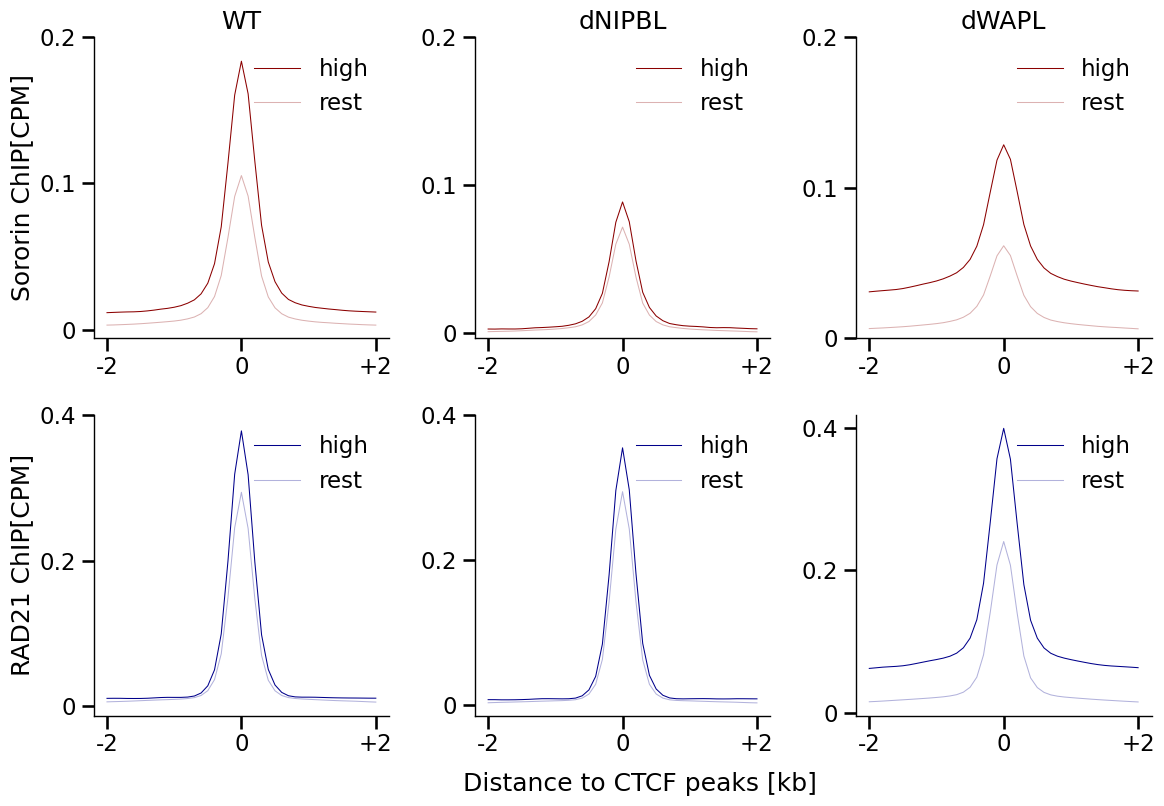

In [55]:
variable='high'
proteins = ('Sororin', 'RAD21')
conditions = ('WT', 'dNIPBL', 'dWAPL')

fig, axes = plt.subplots(2, 3, figsize=(12, 8), dpi=100) 

for row_idx, prot in enumerate(proteins):
    for col_idx, cond in enumerate(conditions):
        ax = axes[row_idx, col_idx]
        hmap = hmaps[prot][cond]

        for group, df in ctcf_peaks.groupby(f'{variable}'):
            idx = df.index
            profile = np.nanmean(hmap[idx, :], axis=0)
            norm_profile = profile - gw_means[prot][cond]
            ax.plot(norm_profile,
                     label=group,
                     color=protein_colors[prot],
                     alpha=level_alphas[group],
                     zorder=3,
                     linewidth=0.75)
        ax.set_xticks([0, 20, 40])
        ax.set_xticklabels(['-2', '0', '+2'])
        ax.set_yticks(yticks[prot])
        ax.set_yticklabels(yticklabels[prot])
        ax.legend(frameon=False)
    
        for spine in ax.spines.values():
                spine.set_linewidth(1)
        sns.despine(ax=ax)

        if row_idx == 0:
            ax.set_title(cond)
        if col_idx == 0:
            ax.set_ylabel(f'{prot} ChIP[CPM]')
fig.text(0.4, -0.01, 'Distance to CTCF peaks [kb]')
plt.tight_layout()
plt.show()

# Figure S6A

How many CTCF sites are in boundary regions (50Kb long)?

In [23]:
boundaries_w_peaks = bf.overlap(bf.expand(boundaries, pad=BOUNDARY_PAD), ctcf_peaks, how='left')
boundaries_w_peaks['peak_count'] = (~boundaries_w_peaks['name_'].isna()).astype('int')
peak_count = boundaries_w_peaks.groupby(['chrom', 'start', 'end'])['peak_count'].sum().reset_index()

In [24]:
boundaries_w_count = pd.merge(boundaries, bf.expand(peak_count, pad=-BOUNDARY_PAD), on=('chrom', 'start', 'end'))

In [25]:
level_vs_count = boundaries_w_count.groupby('levelGroup')['peak_count'].value_counts(normalize=True).rename('fraction').reset_index()

Stratify peak counts into 3 large groups

In [26]:
level_vs_count['peak_count_simple'] = level_vs_count['peak_count'].map(lambda x: '0' if x == 0 else '1-2' if x <= 2 else '3+')
level_vs_count_simple = level_vs_count.groupby(['levelGroup', 'peak_count_simple'])['fraction'].sum().reset_index()

/tmp/ipykernel_46307/981877012.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['Low', 'Mid', 'High'], fontsize=8)
/tmp/ipykernel_46307/981877012.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['0', '20', '40', '60'], fontsize=8)


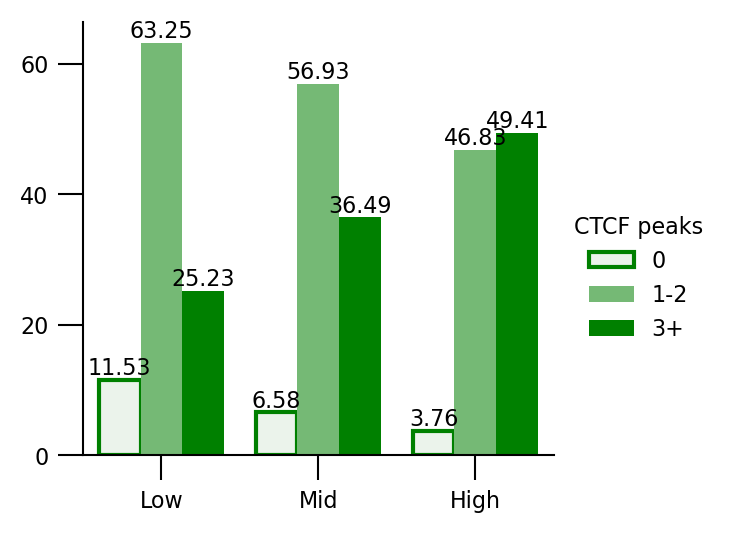

In [43]:
palette = sns.light_palette('green', 3)
with sns.plotting_context('talk'):
    plt.figure(figsize=(4, 3), dpi=200)
    g = sns.barplot(data=level_vs_count_simple, order=['low', 'med', 'high'], hue='peak_count_simple', y='fraction', x='levelGroup', palette=palette, saturation=1)
    for patch in g.patches:
        if patch.get_facecolor()[:3] == palette[0]:
            patch.set_edgecolor(palette[2])
    for container in g.containers:
        plt.bar_label(container, fmt=lambda x: f"{x * 100:.2f}", fontsize=8)
    sns.despine()
    plt.xlabel('')
    plt.ylabel('')
    plt.gca().set_xticklabels(['Low', 'Mid', 'High'], fontsize=8)
    plt.gca().set_yticklabels(['0', '20', '40', '60'], fontsize=8)
    ax = plt.gca()
    ax.tick_params(width=0.75)
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)

    plt.legend(title='CTCF peaks', fontsize=8, title_fontsize=8, frameon=False, bbox_to_anchor=(1, 0.6))
    plt.tight_layout()

# Figure S6C
Average profiles at CTCF peaks with no other peaks nearby

To exclude the possibility that the increased Sororin signal around CTCF peaks is due to other CTCF peaks in +-2.5Kb radius, I will plot profiles separately for CTCF peaks with no other peaks in +-5Kb radius and for CTCF peaks with other peaks in +-2.5Kb radius.

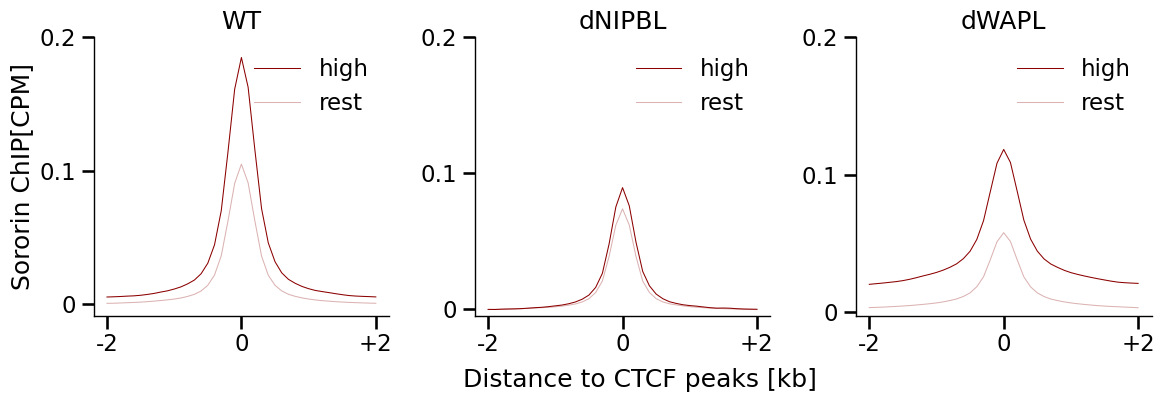

In [56]:
variable='high'
prot = 'Sororin'
subset_func = lambda df: df.query('midpoint_distance > 2_500')
conditions = ('WT', 'dNIPBL', 'dWAPL')

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=100) 


for col_idx, cond in enumerate(conditions):
    ax = axes[col_idx]
    hmap = hmaps[prot][cond]
    for group, df in ctcf_peaks.groupby(f'{variable}'):
        sub_df = subset_func(df)
        idx = sub_df.index
        
        profile = np.nanmean(hmap[idx, :], axis=0)
        norm_profile = profile - gw_means[prot][cond]
        ax.plot(norm_profile,
                 label=group,
                 color=protein_colors[prot],
                 alpha=level_alphas[group],
                 zorder=3,
                 linewidth=0.75)
    ax.set_xticks([0, 20, 40])
    ax.set_xticklabels(['-2', '0', '+2'])
    ax.set_yticks(yticks[prot])
    ax.set_yticklabels(yticklabels[prot])
    ax.legend(frameon=False)

    for spine in ax.spines.values():
            spine.set_linewidth(1)
    sns.despine(ax=ax)
    
    ax.set_title(cond)
    if col_idx == 0:
        ax.set_ylabel(f'{prot} ChIP[CPM]')

fig.text(0.4, -0.01, 'Distance to CTCF peaks [kb]')

plt.tight_layout()
plt.show()